In [132]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [133]:
class BMIState(TypedDict):

  weight_kg : float
  height_m : float
  bmi : float
  category: str

In [134]:
def calculate_bmi(state:BMIState) -> BMIState:


  weight=state['weight_kg']
  height=state['height_m']

  bmi = weight/(height**2)
  state['bmi']=round(bmi,2)

  return state



In [135]:
def get_bmi_category(state: BMIState) -> BMIState:
  bmi = state['bmi']
  if bmi < 18.5:
    state["category"] = "Underweight"
  elif 18.5 <= bmi < 25:
    state ["category"] = "Normal"
  elif 25 <= bmi < 30:
    state ["category"] = "Overweight"
  else:
    state ["category"] = "Obese"
  return state

In [136]:
# Define Graph

graph= StateGraph(BMIState)

# add nodes

graph.add_node("calculate bmi",calculate_bmi)
graph.add_node("label bmi", get_bmi_category)

# add edges

graph.add_edge(START, 'calculate bmi')
graph.add_edge('calculate bmi', 'label bmi')
graph.add_edge('label bmi', END)



#compile graph
workflow = graph.compile()



In [137]:
#execute graph
initial_state = {'weight_kg':90, 'height_m':1.73}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 90, 'height_m': 1.73, 'bmi': 30.07, 'category': 'Obese'}


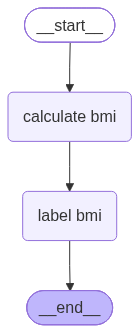

In [138]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))


In [139]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
load_dotenv()

True

In [140]:
model = ChatOpenAI(
    model=os.getenv("TOKENHARBOR_MODEL"),
    api_key=os.getenv("TOKENHARBOR_API_KEY"),
    base_url=os.getenv("TOKENHARBOR_BASE_URL"),
)

In [141]:
# create State

class QA(TypedDict):
  question: str
  answer: str 
  

In [142]:
def llm_qa(state:QA)->QA:

  # Extract a question from the state
  question = state['question']

  # form a prompt
  prompt = f"Answer the following Question {question}, No preamble"

  # Ask Question to the LLM
  answer = model.invoke(prompt).content

  # Update Answer in the state
  state['answer'] = answer
  return state

In [143]:
# Create Graph
graph = StateGraph(QA)

# Add Nodes

graph.add_node('question_answer', llm_qa)

# Add edges

graph.add_edge(START, 'question_answer')
graph.add_edge('question_answer', END)

# Compile graph
workflow= graph.compile()

In [144]:
initial_state = {'question' : 'Who hits the Individual highest score in ODI'}
final_state = workflow.invoke(initial_state)
print(final_state)

{'question': 'Who hits the Individual highest score in ODI', 'answer': 'Rohit Sharma, with 264 runs against Sri Lanka in Kolkata in 2014.'}


In [148]:
initial_state = {'question' : 'what are the most important skills I need to learn in this AI era as a fresher wnats to build career in data science and AI? '}
final_state = workflow.invoke(initial_state)
print(final_state['answer'])

Core skills to prioritize:

1. **Python programming**: Pandas, NumPy, Matplotlib/Seaborn, and clean, modular code with Git and virtual environments.
2. **Statistics and probability**: Descriptive stats, distributions, hypothesis testing, regression, and experimental design. These underpin model choice and interpreting results.
3. **Mathematics for ML**: Linear algebra (vectors, matrices, eigenvalues), calculus (gradients, chain rule), and optimization basics.
4. **SQL and data handling**: Querying, joins, window functions, and working with messy real-world data. Most data roles are SQL-heavy.
5. **Machine learning fundamentals**: Scikit-learn, supervised and unsupervised learning, feature engineering, cross-validation, and evaluation metrics. Understand bias-variance tradeoff and overfitting.
6. **Deep learning and modern AI**: PyTorch (or TensorFlow), neural network architectures, and transformers. Learn how to fine-tune pretrained models.
7. **Large language models and generative AI*

### Prompt chaining

In [149]:
import os
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()

True

In [150]:
model = ChatOpenAI(
    model=os.getenv("TOKENHARBOR_MODEL"),
    api_key=os.getenv("TOKENHARBOR_API_KEY"),
    base_url=os.getenv("TOKENHARBOR_BASE_URL"),
)

In [152]:
# define State
class BlogMaker(TypedDict):
  topic : str
  outline : str
  content : str


In [155]:
# Outline Function
def create_outline(state : BlogMaker) -> BlogMaker:
  # Extract topic
  topic=state['topic']

  # Prompt and Generate with LLM
  prompt=f"Generate the outline of the topic {topic}"
  outline = model.invoke(prompt).content
  state['outline'] = outline
  return state


In [156]:
#Blog Content Generation Content
def create_blog(state: BlogMaker) -> BlogMaker:
  #extract topic and outline
  topic=state['topic']
  outline=state['outline']

  # Generate Blog
  prompt = f"Write a detailed blog on the title - {topic} using the following outline - {outline}"

  blog = model.invoke(prompt)

  #update content
  state['content'] = blog

  return state

In [158]:
# Define Graph
graph = StateGraph(BlogMaker)

# add nodes
graph.add_node("Create outline", create_outline)
graph.add_node("Create blog", create_blog)

# add edges
graph.add_edge(START, "Create outline")
graph.add_edge("Create outline", "Create blog")
graph.add_edge("Create blog", END)

# Compile 
workflow = graph.compile()

In [159]:
initial_state = {'topic': 'AI in Agriculture'}
final_state = workflow.invoke(initial_state)


In [160]:
print(final_state['outline'])

# Outline: AI in Agriculture

## I. Introduction
- A. Definition of Artificial Intelligence in agriculture
- B. Global food security challenges (population growth, climate change, resource scarcity)
- C. Evolution from traditional farming to precision and smart agriculture
- D. Purpose and scope of the discussion

## II. Foundations of AI in Agriculture
- A. Core AI technologies
  - 1. Machine learning
  - 2. Deep learning and computer vision
  - 3. Natural language processing
  - 4. Robotics and automation
- B. Supporting technologies
  - 1. Internet of Things (IoT) sensors
  - 2. Big data analytics
  - 3. Cloud and edge computing
  - 4. Satellite imagery and remote sensing
  - 5. Drones (UAVs)

## III. Applications in Crop Production
- A. Precision planting and seed selection
- B. Soil health monitoring and analysis
- C. Irrigation management and water optimization
- D. Nutrient and fertilizer management
- E. Crop yield prediction and forecasting
- F. Weed detection and selective her

In [165]:
print(final_state['content'].content)

# AI in Agriculture: How Intelligent Machines Are Helping Feed a Changing World

*Farming has always been a contest between human ingenuity and nature's unpredictability. Artificial intelligence is changing the terms of that contest.*

---

## I. Introduction

### A. What Is Artificial Intelligence in Agriculture?

Artificial intelligence (AI) in agriculture refers to the use of computer systems that can learn from data, recognize patterns, make predictions, and sometimes act autonomously to support farming decisions and operations. Rather than relying solely on a farmer's experience, intuition, or periodic manual inspections, AI-enabled systems can continuously analyze information from fields, animals, machines, markets, and weather to recommend or carry out actions.

In practice, this might mean a camera mounted on a sprayer that distinguishes a weed from a crop plant in milliseconds, a model that predicts a wheat crop's yield three months before harvest, or a collar on a dairy cow t